In [75]:
import sys
import os
import glob 


sys.path.append('/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/src')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sc

import plotly.express as px
import plotly.graph_objects as go

import collections

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import treewater.utils as utils


In [76]:
import importlib
import treewater.utils as utils
importlib.reload(utils)

<module 'treewater.utils' from '/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/src/treewater/utils.py'>

key question:
- time series and other features? 

In [96]:
derived_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/data"
data_dir = "/cluster/home/taoj/work_dir/eth-caipstone/tree-water-deficit/data/tstoy04"
model_performance_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived/model_performance"
# data_dir = "/workspaces/eth-capstone-treewater-deficit/data/tstoy04"
# derived_path = "/workspaces/eth-capstone-treewater-deficit/data"

In [72]:
df_series_all = pd.read_csv(os.path.join(derived_path, "twd_tree_series_all.csv"))
twd_tree_series_sites = pd.read_csv(os.path.join(derived_path, "twd_tree_series_sites.csv"))

In [73]:
df_series_all.head(10)
# twd_tree_series_sites.head(10)

,ts,twd,pr,at,ws,dp,sr,lr,series,site_name,species,series_no,Wt,year,month,year_month
0,2020-01-01,0.000000,-4.967054e-09,0.684757,1.197186,-3.640214,62.291590,212.325577,series_06,Bachtel-Forest,Fagus sylvatica,1,NaN,2020,1,2020-01
1,2020-01-02,0.121408,-1.092752e-07,0.213088,1.312338,-4.036302,60.923900,219.828021,series_06,Bachtel-Forest,Fagus sylvatica,1,0.121408,2020,1,2020-01
2,2020-01-03,0.118271,1.285767e-01,2.009851,2.115951,-0.953911,55.859708,275.925156,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.003137,2020,1,2020-01
3,2020-01-04,0.000000,9.927122e-02,1.573278,3.247398,0.721803,13.914832,311.878969,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.118271,2020,1,2020-01
4,2020-01-05,0.000000,-1.986821e-08,-0.442240,2.159941,-4.094125,62.620516,216.038632,series_06,Bachtel-Forest,Fagus sylvatica,1,0.000000,2020,1,2020-01
5,2020-01-06,0.000000,3.880511e-10,1.900865,1.479226,-5.472837,63.572741,220.306782,series_06,Bachtel-Forest,Fagus sylvatica,1,0.000000,2020,1,2020-01
6,2020-01-07,0.593406,2.411429e-02,1.480216,2.514120,-1.105571,26.014536,265.315427,series_06,Bachtel-Forest,Fagus sylvatica,1,0.593406,2020,1,2020-01
7,2020-01-08,0.557187,-6.457170e-07,3.140700,2.099829,-7.224881,48.464034,265.264362,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.036220,2020,1,2020-01
8,2020-01-09,0.918142,-1.182159e-06,5.119999,1.631017,-5.251706,58.383674,248.506977,series_06,Bachtel-Forest,Fagus sylvatica,1,0.360955,2020,1,2020-01
9,2020-01-10,1.269509,5.132516e-03,3.655803,3.022984,-0.587912,39.215077,289.792323,series_06,Bachtel-Forest,Fagus sylvatica,1,0.351367,2020,1,2020-01


start from simple model 
- understand the covariance, mean a little better
- gaussian process
- autoregressive model 

1. autoregressive


it seems the lag can be 13... 
- use 13 previous twd observations to build autoregressive model?
- use exogenous variables? 


## data preparation

take median value of same site, same species of twd


? what about temperaturre
 (haven't tested if the same..on the same day at the same site)

In [7]:
df_series_all.head()


,ts,twd,pr,at,ws,dp,sr,lr,series,site_name,species,series_no,Wt,year,month,year_month
0,2020-01-01,0.000000,-4.967054e-09,0.684757,1.197186,-3.640214,62.291590,212.325577,series_06,Bachtel-Forest,Fagus sylvatica,1,NaN,2020,1,2020-01
1,2020-01-02,0.121408,-1.092752e-07,0.213088,1.312338,-4.036302,60.923900,219.828021,series_06,Bachtel-Forest,Fagus sylvatica,1,0.121408,2020,1,2020-01
2,2020-01-03,0.118271,1.285767e-01,2.009851,2.115951,-0.953911,55.859708,275.925156,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.003137,2020,1,2020-01
3,2020-01-04,0.000000,9.927122e-02,1.573278,3.247398,0.721803,13.914832,311.878969,series_06,Bachtel-Forest,Fagus sylvatica,1,-0.118271,2020,1,2020-01
4,2020-01-05,0.000000,-1.986821e-08,-0.442240,2.159941,-4.094125,62.620516,216.038632,series_06,Bachtel-Forest,Fagus sylvatica,1,0.000000,2020,1,2020-01


In [8]:
# test if in the same day same site, temp and other features are the same

sites = df_series_all['site_name'].unique()
for site in sites:
    df_site = df_series_all.loc[df_series_all.site_name == site, ]
    series = df_site.series_no.unique()
    if len(series) >=2:
        series_1 = df_site.loc[df_site.series_no == series[0], ]
        series_2 = df_site.loc[df_site.series_no == series[1], ]
        merged = pd.merge(series_1, series_2, on='ts', suffixes=('_1', '_2'))
        temp_equal = all(merged['at_1'] == merged['at_2'])
        pr_equal = all(merged['pr_1'] == merged['pr_2'])
        dp_equal = all(merged['dp_1'] == merged['dp_2'])
        sr_equal = all(merged['sr_1'] == merged['sr_2'])
        if not (temp_equal and pr_equal and dp_equal and sr_equal):
            print(f"Data mismatch found in site {site} between series {series[0]} and {series[1]}")

# so far they are no mismatch found, all the other measurements are the same for different series in the same site


In [9]:
# twd_tree_series_sites

In [10]:
# Psudotsuga mnzisii", from site "Multi-Forest" in 2021, 2022 exluded
df_series_all = df_series_all.loc[~((df_series_all.species == "Psudotsuga mnzisii") & (df_series_all.site_name == "Multi-Forest") & (df_series_all.year.isin([2021, 2022]))), ]
df_series_all_median = df_series_all.groupby(['site_name', 'species', 'ts']).agg({'twd': 'median',  'year': 'first',
                                                                                 'pr': 'median', 'at': 'median', "ws": 'median', 'dp': 'median',
                                                                                 'sr': 'median', 'lr':'median'}).reset_index() 

df_series_all_median= df_series_all_median.merge(twd_tree_series_sites[['site_name', 'species', 'mch_elevation', "mch_easting",
                                                                        "mch_northing"]].drop_duplicates(), on=['site_name', 'species'], how='left')

In [11]:
# transform species to categorical variable - using ohe-hot encoding
# Get one hot encoding of columns B
one_hot = pd.get_dummies(df_series_all_median['species'],dtype=float)
# Drop column B as it is now encoded, hmm maybe not yet
df_series_all_features = df_series_all_median
# Join the encoded df
df_series_all_features = df_series_all_features.join(one_hot.iloc[: , 0:6])
# drop useless features 
df_series_features = df_series_all_features.drop(columns=['year'])



In [12]:
# create a dataframe with log2 transformed twd values
df_series_features_log2 = df_series_features.copy()
epsilon = 1
df_series_features_log2['twd'] = np.log2(epsilon+ df_series_features_log2['twd'])

split the data into training and test set
 - train and test set split by an even distribution of sites? 
 - easting and northing recommended
 - if autoregressive with lag =13
    - label: twd_t
    - input feature: [twd_t-12, twd_t-11, ...twd_t-1, at_t-1, lt_t-1]? 
    - can i use at_t as input feature?


Normalize certain colums: 

- pr	at	ws	dp	sr	lr	mch_elevation	site_longitude	site_latitude
- if twd was treated as feature should we then standardize it when model is autoregressive? 
- should we normalize it before or after splitting by windows? - i guess really no harm either way 

In [14]:
# create a dataframe with log2 transformed twd values
df_series_features_log2 = df_series_features.copy()
df_series_features_log2['twd'] = np.log2(1 + df_series_features_log2['twd'])

In [34]:
# Configure features
config = FeatureConfig()
lag_n =7

# Split data
train_df_at, val_df_at, test_df_at = utils.create_training_test_set_optimized(
    df_series_features_log2,
    feature_window_size=lag_n,
    autoregressive=True
)


train_df_at, val_df_at, test_df_at = utils.standardize_dataset(
    train_df_at, val_df_at, test_df_at
)

# Create windows
train_X_at, train_y_at = utils.spliting_windows_df(
    train_df_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config=config
)

val_X_at, val_y_at = utils.spliting_windows_df(
    val_df_at,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=True,
    shift = 1,
    config=config
)

# non-autoregressive

train_df, val_df, test_df = utils.create_training_test_set_optimized(
    df_series_features_log2, 
    feature_window_size=lag_n,
    autoregressive=False)

train_df, val_df, test_df = utils.standardize_dataset(
    train_df, val_df, test_df
)


train_X, train_y = utils.spliting_windows_df(
    train_df,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive=False,
    shift = 1,
    config=config
)

val_X, val_y = utils.spliting_windows_df(
    val_df,
    feature_window_size=lag_n,
    label_window_size = 1,
    autoregressive = False,
    shift = 1,
    config = config)


# create autoregressive at cross validation datasets

train_val_datasets_at = utils.cross_validate_datasets(
    train_df_at, n_splits=4, feature_window_size=lag_n,  config=config) # dataframe should be standardized


cv_train_val_at = []
for train_cv_df_at, val_cv_df_at in train_val_datasets_at:
    train_cv_X_at, train_cv_y_at = utils.spliting_windows_df(
        train_cv_df_at,
        feature_window_size=lag_n,
        label_window_size = 1,
        autoregressive=True,
        shift = 1,
        config=config
    )
    
    val_cv_X_at, val_cv_y_at = utils.spliting_windows_df(
        val_cv_df_at,
        feature_window_size=lag_n,
        label_window_size = 1,
        autoregressive=True,
        shift = 1,
        config=config
    )
    
    cv_train_val_at.append((train_cv_X_at, train_cv_y_at, val_cv_X_at, val_cv_y_at))

## build simple models - baseline
-  linear regression: autoregressive and non-autoregressive

#### non-Autoregressive
feature selected: 
- 7 days of non-static features (excluding twd) + geo location + species

label:
- twd at day 7
- using log2 transformed values to train the model to avoid non-zero values
 

In [77]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import root_mean_squared_error, r2_score

In [36]:
rgr = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 2, 5]).fit(train_X, np.log2(1+train_y))
rgr.score(train_X, np.log2(1+train_y))

0.40638704122342983

In [37]:
rmse_train = root_mean_squared_error(train_y, utils.clip_and_inverse_log2_transform(rgr.predict(train_X)))
y_pred_val = utils.clip_and_inverse_log2_transform(rgr.predict(val_X))
rmse_val = root_mean_squared_error(val_y,  y_pred_val)
r2 = r2_score(val_y, y_pred_val)

/scratch/tmp.56488163.taoj/ipykernel_3846621/1057981882.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_range,x_range, 'k--',
/scratch/tmp.56488163.taoj/ipykernel_3846621/1057981882.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_range, [i+rmse_scatter for i in x_range], 'k--',
/scratch/tmp.56488163.taoj/ipykernel_3846621/1057981882.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_range, [i-rmse_scatter for i in x_range], 'k--',


Text(1.7188471619402197, 0.5, 'RMSE: 0.397\n R2: 0.528')

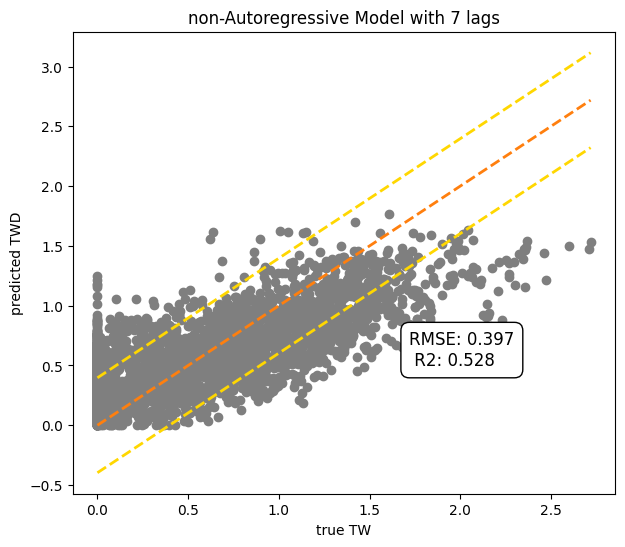

In [38]:
x_scatter = val_y
y_scatter = y_pred_val
rmse_scatter = rmse_val
plt.figure(figsize=(7,6))
plt.scatter(x =x_scatter, y =y_scatter, color = "tab:grey")
plt.xlabel("true TW")
plt.ylabel("predicted TWD")
x_range = [x_scatter.min(), x_scatter.max()]
# how to plot y= x? 
plt.plot(x_range,x_range, 'k--', 
lw=2, color = "tab:orange")
# can i plot two lines showing the rmse range?
plt.plot(x_range, [i+rmse_scatter for i in x_range], 'k--', 
lw=2, color = "gold")
plt.plot(x_range, [i-rmse_scatter for i in x_range], 'k--', 
lw=2, color = "gold")
plt.title(f"non-Autoregressive Model with {lag_n} lags")
plt.text(x_scatter.max()-1, y_scatter.min()+0.5, f"RMSE: {rmse_scatter:.3f}\n R2: {r2:.3f}", 
         fontsize=12, color="black",
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


it looks like it randomly predict value within the range of 0-2

### Autogressive model
feature selected: 
- 7 days of non-static features (including twd) + geo location + species + 1st day of non-static features (excluding twd)

label:
- twd at day 7

In [ ]:
rmses_cv_at, rmses_cv_1d_at, r2s_cv_1d_at, r2s_cv_at, y_preds_cv_at, y_trues_cv_at= utils.cross_validation_ridge(cv_train_val_at, 
                                                                                                           train_val_datasets_at, 
                                                                                                           lag_n, config, 
                                                                                                           if_log = True)


                                                                                                           

Training fold 1/4
Training fold 2/4
Training fold 3/4
Training fold 4/4


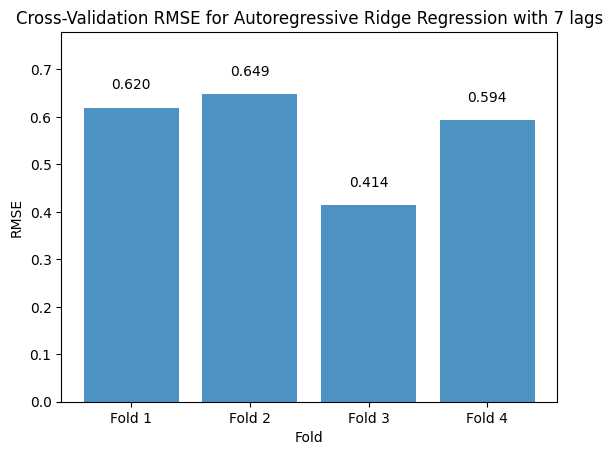

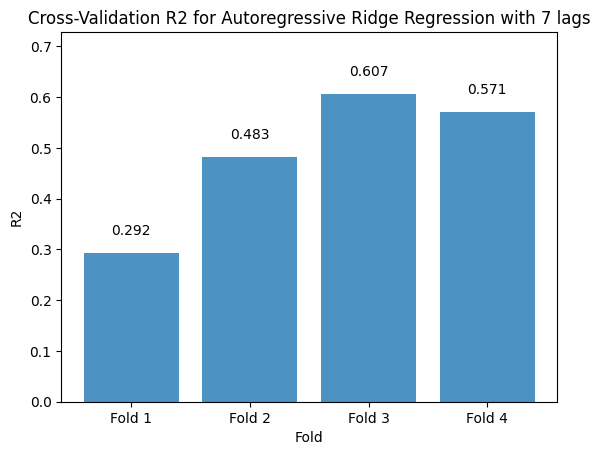

In [85]:
# visualize results
plt.bar(range(len(rmses_cv_at)), rmses_cv_at, color = "tab:blue", alpha = 0.8)
plt.xticks(range(len(rmses_cv_at)), [f"Fold {i+1}" for i in range(len(rmses_cv_at))])
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title(f"Cross-Validation RMSE for Autoregressive Ridge Regression with {lag_n} lags")
plt.ylim(0, max(rmses_cv_at)*1.2)
for i, rmse in enumerate(rmses_cv_at):
    plt.text(i, rmse + max(rmses_cv_at)*0.05, f"{rmse:.3f}", ha='center', va='bottom')
plt.show()  


# visualize results
plt.bar(range(len(r2s_cv_at)), r2s_cv_at, color = "tab:blue", alpha = 0.8)
plt.xticks(range(len(r2s_cv_at)), [f"Fold {i+1}" for i in range(len(r2s_cv_at))])
plt.xlabel("Fold")
plt.ylabel("R2")
plt.title(f"Cross-Validation R2 for Autoregressive Ridge Regression with {lag_n} lags")
plt.ylim(0, max(r2s_cv_at)*1.2)
for i, r2 in enumerate(r2s_cv_at):
    plt.text(i, r2 + max(r2s_cv_at)*0.05, f"{r2:.3f}", ha='center', va='bottom')
plt.show()  

In [97]:
# save CV results


df_model_performance = pd.DataFrame({
    "model" :['Ridge_at'] *4 ,
    "cv_fold"  : [i for i in range(1, len(rmses_cv_at) + 1)],
    "mae": [0]*4,
    "rmse_recursive": rmses_cv_at, 
    "rmse_1day": rmses_cv_1d_at ,
    "r2_1day" : r2s_cv_1d_at ,
    "r2_recursive": r2s_cv_at,
    "lag_n": [lag_n] * 4

}
)

df_model_performance.to_csv(os.path.join(model_performance_path, f"ridge_at_cv_results_lag{lag_n}.csv"), index=False)


In [39]:

rgr_at = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 2, 5]).fit(train_X_at, train_y_at)
rgr_at.score(train_X_at, train_y_at)

rmse_train_at = root_mean_squared_error(train_y_at, rgr_at.predict(train_X_at))



fix-horizon prediction, shift 1,3,5? 

autogressive on validation set and test set : forecasting using the value that was predicted 


In [40]:
rgr_at.score(train_X_at, train_y_at)

0.9147980102566624

In [41]:
# compute model performance on validation set using recursive prediction
y_pred_val_at,  val_y_rgr_at = utils.compute_recursive_predictions(rgr_at, val_df_at, feature_window_size=lag_n)
# for the purpose of compare outputs from two function compute_recursive_predictions and compute_recursive_predictions_fast
y_pred_val_at_fast,  val_y_at_fast = utils.compute_recursive_predictions_fast(rgr_at, val_df_at, feature_window_size=lag_n,
                                                              tensor = False)



In [42]:
# compute 1-day ahead prediction performance for comparison
y_pred_1d_val_at_rgr = utils.clip_and_inverse_log2_transform(rgr_at.predict(val_X_at).reshape(-1))
# clip and inverse log2 transform
y_pred_val_at = utils.clip_and_inverse_log2_transform(y_pred_val_at)
y_pred_val_at_fast = utils.clip_and_inverse_log2_transform(y_pred_val_at_fast)


r2_rgr_at_1day = r2_score(np.power(2, val_y_rgr_at)-1, y_pred_1d_val_at_rgr)

r2_rgr_at_fast = r2_score(np.power(2, val_y_at_fast)-1, y_pred_val_at_fast)
rmse_rgr_at_fast = root_mean_squared_error(np.power(2, val_y_at_fast)-1, y_pred_val_at_fast)

rmse_val_at = root_mean_squared_error(np.power(2, val_y_rgr_at)-1, y_pred_val_at)
r2_at = r2_score(np.power(2, val_y_rgr_at)-1, y_pred_val_at)
print(rmse_val_at, r2_at)
print(rmse_rgr_at_fast, r2_rgr_at_fast)

0.456668299343244 0.6665259031006622
0.456668299343244 0.6665259031006622


/scratch/tmp.56488163.taoj/ipykernel_3846621/2001946190.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
/scratch/tmp.56488163.taoj/ipykernel_3846621/2001946190.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i+rmse_val_at for i in x_range], 'k--', lw=2, color="gold")
/scratch/tmp.56488163.taoj/ipykernel_3846621/2001946190.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i-rmse_val_at for i in x_range], 'k--', lw=2, color="gold")
/scratch/tmp.56488163.taoj/ipykernel_3846621/2001946190.py:47: UserWarning: color is redundantly defined by the 'c

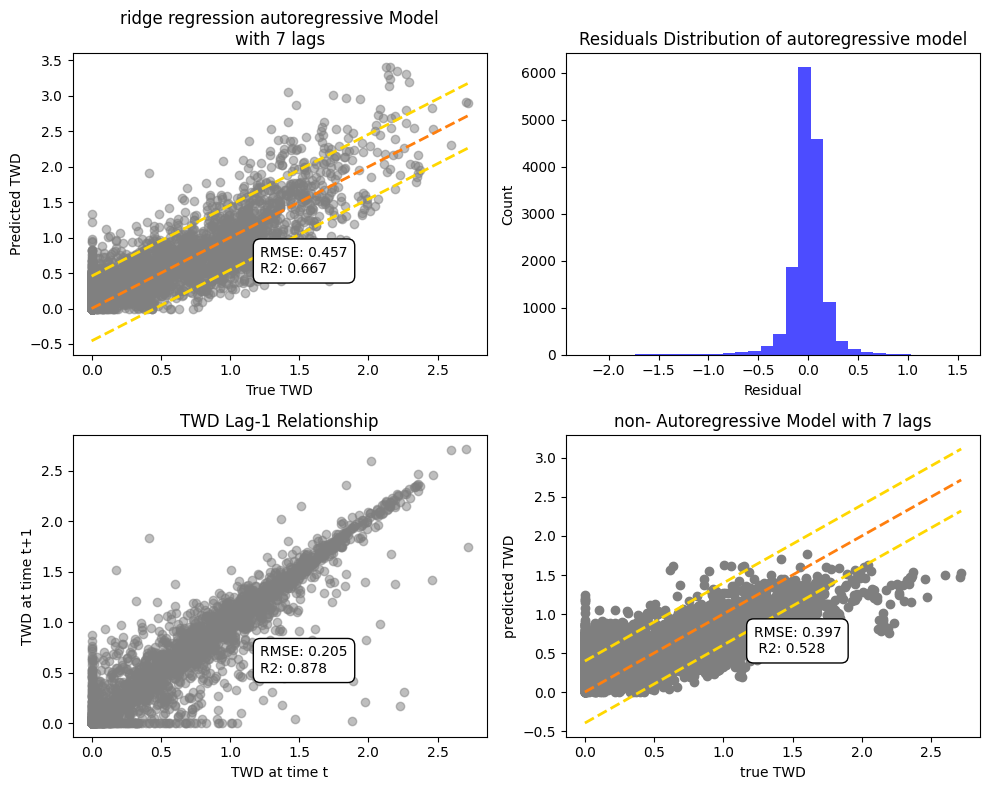

In [43]:
# Create figure with 3 subplots arranged in 1 row and 3 columns
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

# First subplot - Autoregressive Model Predictions
ax1.scatter(x=val_y_at, y=y_pred_val_at, color="grey", alpha=0.5)
ax1.set_xlabel("True TWD")
ax1.set_ylabel("Predicted TWD")
x_range = [val_y_at.min(), val_y_at.max()]
ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
ax1.plot(x_range, [i+rmse_val_at for i in x_range], 'k--', lw=2, color="gold")
ax1.plot(x_range, [i-rmse_val_at for i in x_range], 'k--', lw=2, color="gold")
ax1.set_title(f"ridge regression autoregressive Model\nwith {lag_n} lags")
ax1.text(val_y_at.max()-1.5, y_pred_val_at.min()+0.5, 
         f"RMSE: {rmse_val_at:.3f}\nR2: {r2_at:.3f}", 
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


# Second subplot - Residuals histogram
y_res = train_y_at.reshape(-1) - rgr_at.predict(train_X_at)
ax2.hist(y_res, bins=30, color='blue', alpha=0.7)
ax2.set_xlabel("Residual")
ax2.set_ylabel("Count")
ax2.set_title("Residuals Distribution of autoregressive model")



# Third subplot - Lag-1 TWD relationship
rmse_lag1 = root_mean_squared_error(val_df["twd"][:-1], val_df['twd'][1:])
r2_score_lag1 = r2_score(val_df["twd"][:-1], val_df['twd'][1:])
ax3.scatter(val_df["twd"][:-1], val_df['twd'][1:], color='tab:grey', alpha=0.5)
ax3.set_xlabel("TWD at time t")
ax3.set_ylabel("TWD at time t+1")
ax3.set_title("TWD Lag-1 Relationship")
ax3.text(val_df["twd"][:-1].max()-1.5, val_df['twd'][1:].min()+0.5, 
         f"RMSE: {rmse_lag1:.3f}\nR2: {r2_score_lag1:.3f}", 
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# add non-auto regressive model results
x_scatter = val_y
y_scatter = y_pred_val
rmse_scatter = rmse_val
ax4.scatter(x =x_scatter, y =y_scatter, color = "tab:grey")
ax4.set_xlabel("true TWD")
ax4.set_ylabel("predicted TWD")
x_range = [x_scatter.min(), x_scatter.max()]
# how to plot y= x? 
ax4.plot(x_range,x_range, 'k--', 
lw=2, color = "tab:orange")
# can i plot two lines showing the rmse range?
ax4.plot(x_range, [i+rmse_scatter for i in x_range], 'k--', 
lw=2, color = "gold")
ax4.plot(x_range, [i-rmse_scatter for i in x_range], 'k--', 
lw=2, color = "gold")
ax4.set_title(f"non- Autoregressive Model with {lag_n} lags")
ax4.text(x_scatter.max()-1.5, y_scatter.min()+0.5, f"RMSE: {rmse_scatter:.3f}\n R2: {r2:.3f}", 
         fontsize=10, color="black",
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))



# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [48]:

y_pred_test_at,  test_y_at= utils.compute_recursive_predictions_fast(rgr_at, test_df_at, feature_window_size=lag_n,
                                                              tensor = False)

0.7594653209343861
0.5902556031122357


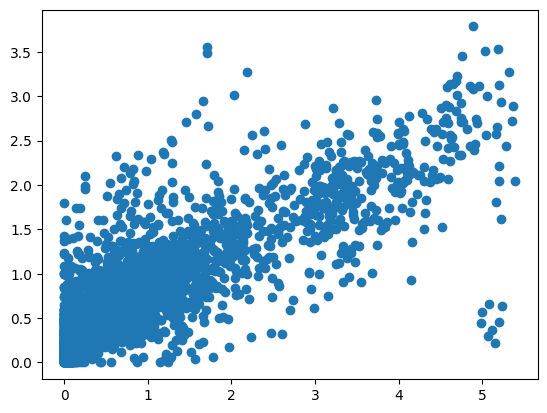

In [56]:
rmse_test_at = root_mean_squared_error(np.power(2, test_y_at)-1,
                                       utils.clip_and_inverse_log2_transform(y_pred_test_at))
r2_test_at = r2_score(np.power(2, test_y_at)-1, utils.clip_and_inverse_log2_transform(y_pred_test_at))

print(rmse_test_at)
print(r2_test_at)

plt.scatter(np.power(2, test_y_at)-1, utils.clip_and_inverse_log2_transform(y_pred_test_at))

we can see that model isn't great at predicting near 0 values


let's use ridge regression as a benchmark (baseline), 
- but it is also important to understand which feature are important
- what are the outliers in the prediction
- take a look at residual?
- also wondering if we use TWD from the previous day, how would that change the prdiction? 

Ridge regression performs slightly better than twd from the day before

let's take a look at feature importance

/scratch/tmp.56488163.taoj/ipykernel_3846621/1948271559.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize= 6)


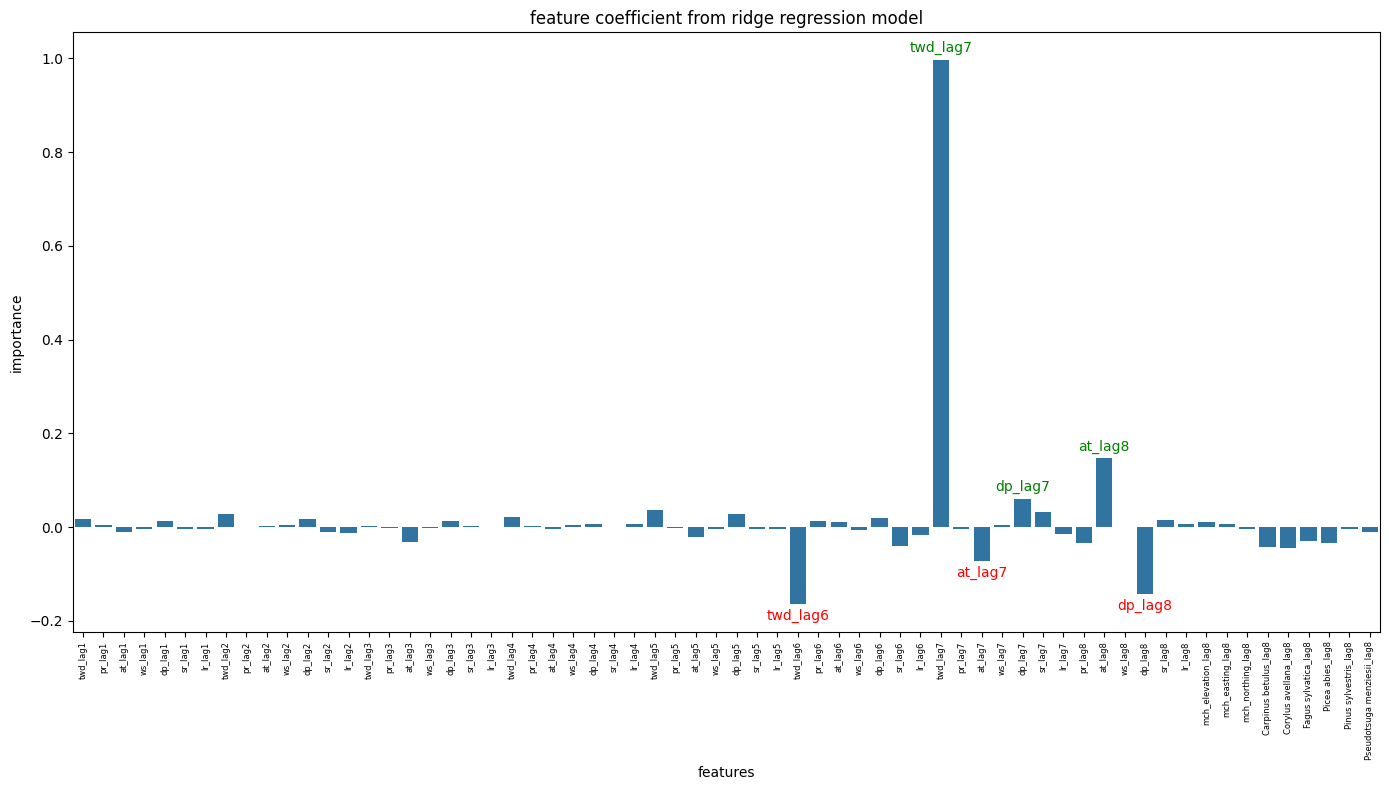

/scratch/tmp.56488163.taoj/ipykernel_3846621/1948271559.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize= 10)


Text(0.5, 1.0, 'feature coefficient (abs(feature_coef) > 0.02)# from ridge regression model')

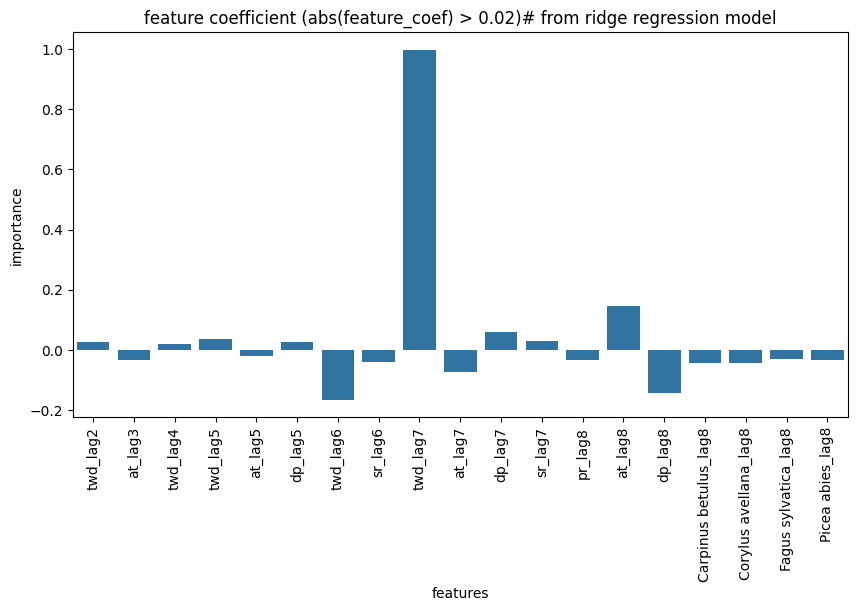

In [47]:
features_ts_cols = ['twd', 'pr', 'at', 'ws', 'dp', 'sr', 'lr']
features_ts_cols_wo_twd = ['pr', 'at', 'ws', 'dp', 'sr', 'lr']
features_static_cols = ['mch_elevation', 'mch_easting', 'mch_northing', 'Carpinus betulus',
       'Corylus avellana', 'Fagus sylvatica', 'Picea abies',
       'Pinus sylvestris', 'Pseudotsuga menziesii']

plt.figure(figsize=(14,8))
lag_labels_at = []
n_lag = 7
for i in range(1, n_lag +2):  # 24 lags
    if i == n_lag+1:
        lag_labels_at.extend([f"{col}_lag{i}" for col in features_ts_cols_wo_twd + features_static_cols])
    else:
        lag_labels_at.extend([f"{col}_lag{i}" for col in features_ts_cols])

# lag_labels = [i if "twd" in i else "" for i in lag_labels]
df_reg_imp = pd.DataFrame({
    "features": lag_labels_at,
    "importance": rgr_at.coef_}
)
# df_plot = df_reg_imp.loc[df_reg_imp.importance.abs()>0.05]
df_plot = df_reg_imp
ax = sns.barplot(df_plot, x = "features", y = "importance")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize= 6)
ax.set_title("feature coefficient from ridge regression model")
threshold = 0.05
for i, (feature, imp) in enumerate(zip(df_reg_imp['features'], df_reg_imp['importance'])):
    if abs(imp) > threshold:
        color = 'red' if imp < 0 else 'green'
        ax.text(i, imp + (0.01 if imp > 0 else -0.01), 
                feature,
                rotation=0,
                ha='center',
                va='bottom' if imp > 0 else 'top',
                fontsize=10,
                color=color)

plt.tight_layout()
plt.show()

# plt.bar(lag_labels, rgr_at.coef_)
# plt.xticks(lag_labels, rotation=90, fontsize = 7)

plt.figure(figsize=(10,5))
df_plot = df_reg_imp.loc[df_reg_imp.importance.abs()>0.02]
ax = sns.barplot(df_plot, x = "features", y = "importance")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize= 10)
ax.set_title("feature coefficient (abs(feature_coef) > 0.02)# from ridge regression model")

dew point: air becomes sauratd with water vapor, direct measure off air moisture

In [31]:
reg_impt_feature_index_at = df_reg_imp.loc[df_reg_imp.importance > 0.01, ].index

reg_impt_feature_index_at
# we can use this for non-linear model

Index([ 7, 13, 21, 23, 32, 33, 35, 44, 49, 53, 63, 70, 74, 78, 79, 81, 84, 88,
       89, 92, 95, 97],
      dtype='int64')